In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Converter TotalCharges para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remover nulos
df = df.dropna()

# Converter churn para binário
df['Churn_Flag'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [7]:
#Taxa de Churn
churn_rate = df['Churn_Flag'].mean()
print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 26.58%


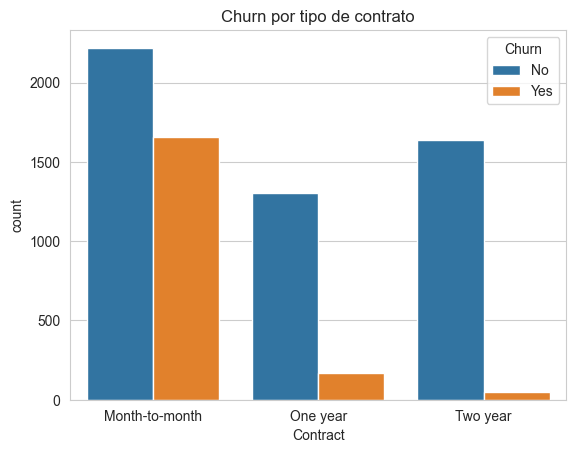

In [ ]:
#Churn por contrato

#Quantos clientes existem em cada tipo de contrato
#Separando quem cancelou (Churn = Yes) e quem não cancelou (No)

sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn por tipo de contrato")
plt.show()

contratos longos geram maior retenção enquanto que contratos mensais tem maior risco de churn


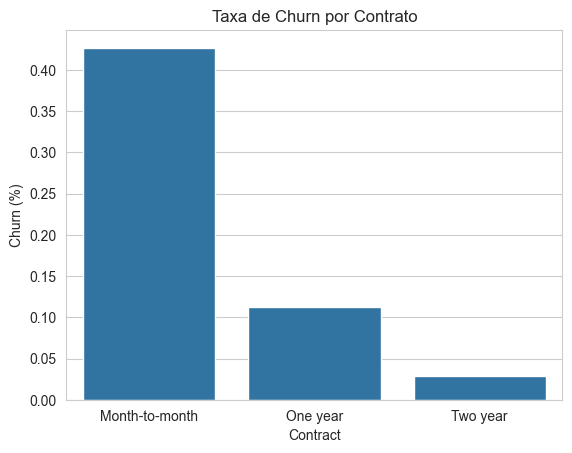

In [10]:
#Taxa de Churn por contrato

print("contratos longos geram maior retenção enquanto que contratos mensais tem maior risco de churn")

churn_by_contract = df.groupby('Contract')['Churn_Flag'].mean().reset_index()

sns.barplot(data=churn_by_contract, x='Contract', y='Churn_Flag')
plt.title("Taxa de Churn por Contrato")
plt.ylabel("Churn (%)")
plt.show()

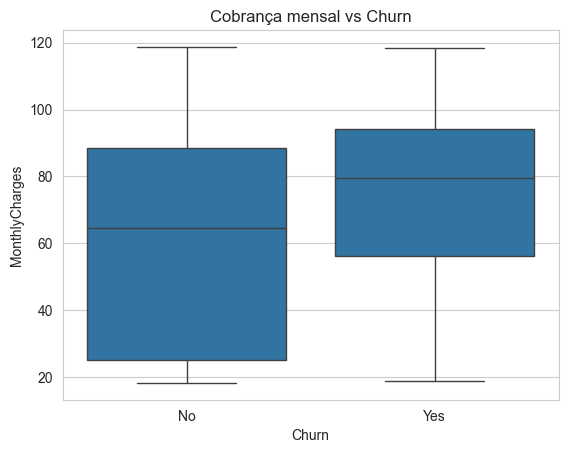

INSIGHT: Clientes que cancelam geralmente têm mensalidades mais altas
Possiveis causas: preço alto, cliente não vê valor no serviço ou concorrência mais barata


In [26]:
#Cobranca mensal
#Gráfico BoxPlot - Quanto os clientes pagam por mês
#Separando entre quem cancelou e quem não cancelou

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Cobrança mensal vs Churn")
plt.show()

print("INSIGHT: Clientes que cancelam geralmente têm mensalidades mais altas")
print("Possiveis causas: preço alto, cliente não vê valor no serviço ou concorrência mais barata")

In [21]:
#comparando média por exemplo
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

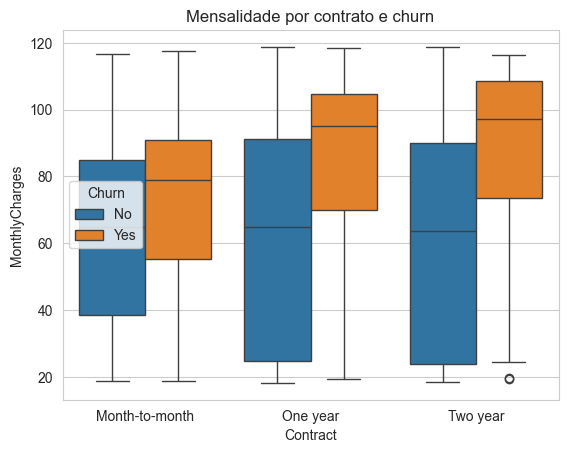

INSIGHT: Clientes com mensalidades mais altas e contratos mensais apresentam maior taxa de churn,
 indicando possível sensibilidade a preço e baixo nível de fidelização.


In [24]:
# Apesar da correlação observada, é necessário investigar outros fatores
# (como tipo de contrato e serviços adicionais) para entender melhor a causa do churn

# cruzar com contrato
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn')
plt.title("Mensalidade por contrato e churn")
plt.show()

#assim é possivel analisar se o problema é preço ou tipo de contrato
print ("INSIGHT: Clientes com mensalidades mais altas e contratos mensais apresentam maior taxa de churn,\n indicando possível sensibilidade a preço e baixo nível de fidelização.")

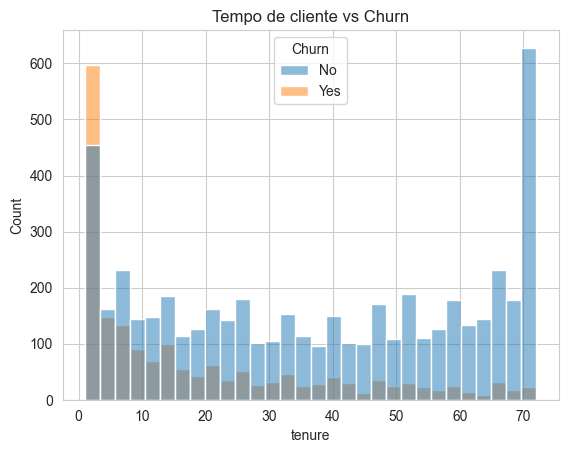

INSIGHT: Clientes com baixo tenure (ex: 0–12 meses) cancelam muito mais 
o chamado churn early-stage (cancelamento precoce)


In [30]:
# Tempo de Cliente (tenure)
#baixo tenure = cliente novo
#alto tenure = cliente antigo

sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title("Tempo de cliente vs Churn")
plt.show()

print("INSIGHT: Clientes com baixo tenure (ex: 0–12 meses) cancelam muito mais \n" \
"o chamado churn early-stage (cancelamento precoce)")
## Indica a necessidade de melhorar onboarding, criar incentivos iniciais e/ou acompanhar clientes novos

C:\Users\User\AppData\Local\Temp\ipykernel_872\3195592718.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby(pd.cut(df['tenure'], bins=[0,12,24,48,72]))['Churn_Flag'].mean()


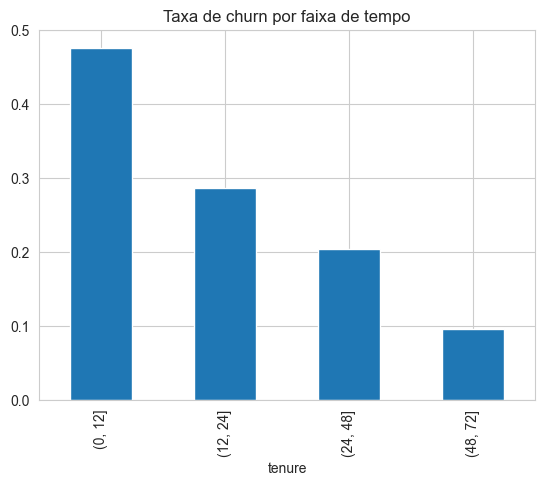

In [28]:
# transformando esse insight em taxa

churn_by_tenure = df.groupby(pd.cut(df['tenure'], bins=[0,12,24,48,72]))['Churn_Flag'].mean()

churn_by_tenure.plot(kind='bar')
plt.title("Taxa de churn por faixa de tempo")
plt.show()

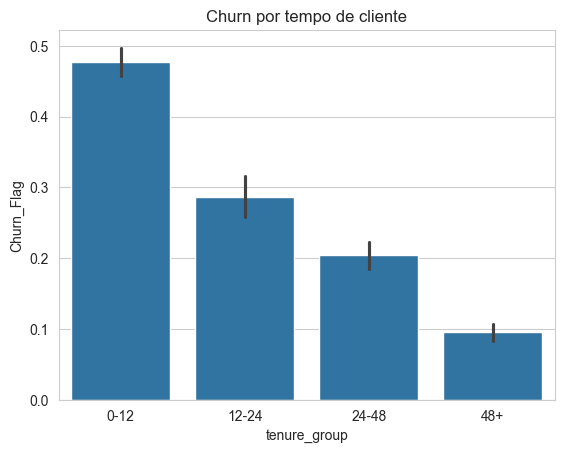

In [29]:
#Categorizando essa analise 

df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                           labels=['0-12','12-24','24-48','48+'])

sns.barplot(data=df, x='tenure_group', y='Churn_Flag')
plt.title("Churn por tempo de cliente")
plt.show()